In [1]:
import re
import time
import json
import ast
from pprint import pprint
from functools import reduce
from collections import Counter, namedtuple

import pandas as pd
import numpy as np
import requests

import jieba
from nltk import ngrams, FreqDist

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.preprocessing import LabelBinarizer, MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.multiclass import OneVsRestClassifier

from sklearn.metrics import (
    confusion_matrix,
    multilabel_confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    RocCurveDisplay,
    jaccard_score,
    make_scorer
)


import pyLDAvis
import pyLDAvis.gensim_models
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel, LdaMulticore
from gensim.matutils import corpus2csc, corpus2dense, Sparse2Corpus
from gensim.models.phrases import Phrases, Phraser

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# 設定圖的中文字體與負號顯示
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # Windows
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac 使用者請改用此行
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', None)

DATA_PATH = "data/movies_label.csv"
JIEBA_DICT_PATH = "./dict/dict.txt.big"
STOPWORDS_PATH = "./dict/stop_words.txt"

RANDOM_STATE = 2024
PASSES = 20
ITERATIONS = 200
NO_BELOW = 5
NO_ABOVE = 0.8
KEEP_N = 5000
TOPIC_RANGE = range(2, 11)

d:\media\venv\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
d:\media\venv\Lib\site-packages\matplotlib\_fontconfig_pattern.py:88: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
d:\media\venv\Lib\site-packages\matplotlib\_fontconfig_pattern.py:92: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
d:\media\venv\Lib\site-packages\matplotlib\_fontconfig_pattern.py:88: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
d:\media\venv\Lib\site-packages\matplotlib\_fontconfig_pattern.py:92: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser

## 資料處理

In [2]:
movies = pd.read_csv("data/movies_label.csv")  # 匯資料
print(f"number of posts: {movies.shape[0]}")
movies.head(3)

number of posts: 2000


,adult,backdrop_path,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genre_label
0,False,/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg,1226863,en,The Super Mario Galaxy Movie,面對反派勢力再度崛起，瑪利歐也為蘑菇王國挺身而出迎戰，大喊：「先過我這一關！」碧姬公主則與奇諾比奧迅速打包啟程，前往銀河尋找羅潔塔公主；一群色彩繽紛又可...,828.4621,/yAI5H1T6qzFPHml5PFC7rthjRU3.jpg,2026-04-01,超級瑪利歐銀河電影版,False,6.800,521,家庭、喜劇、冒險、奇幻、動畫
1,False,/1x9e0qWonw634NhIsRdvnneeqvN.jpg,1523145,ru,Твоё сердце будет разбито,NaN,434.1481,/iGpMm603GUKH2SiXB2S5m4sZ17t.jpg,2026-03-26,Твоё сердце будет разбито,False,7.094,65,愛情、劇情
2,False,/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg,83533,en,Avatar: Fire and Ash,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里、妻子納美戰士奈蒂莉及蘇里的家人一同，在經歷奮戰與傷痛後，依然必須展開全新冒險，也將面臨新登場反派的威脅。,329.6580,/wCqdYTvQSNITnTUrJ5xwzSMrAB1.jpg,2025-12-17,阿凡達：火與燼,False,7.372,2645,科幻、冒險、奇幻


In [3]:
# 過濾 nan 的資料
movies = movies.dropna(subset=['overview', 'title', 'genre_label'], how='any')

# 只留中文字
movies["overview"] = movies.overview.apply(
    lambda x: re.sub("[^\u4e00-\u9fa5]+", "", x)
)
# movies["overview"] = movies["overview"].str.replace(r'[^\u4e00-\u9fa5]+', '', regex=True)
movies["title"] = movies["title"].apply(
    lambda x: re.sub("[^\u4e00-\u9fa5]+", "", x)
)

# 只留下 title 也是中文的資料（即清理後 title 不為空的）
movies = movies[movies['title'] != '']

print(f"number of posts: {movies.shape[0]}")
movies.head(3)

number of posts: 1768


,adult,backdrop_path,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genre_label
0,False,/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg,1226863,en,The Super Mario Galaxy Movie,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列,828.4621,/yAI5H1T6qzFPHml5PFC7rthjRU3.jpg,2026-04-01,超級瑪利歐銀河電影版,False,6.800,521,家庭、喜劇、冒險、奇幻、動畫
2,False,/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg,83533,en,Avatar: Fire and Ash,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,329.6580,/wCqdYTvQSNITnTUrJ5xwzSMrAB1.jpg,2025-12-17,阿凡達火與燼,False,7.372,2645,科幻、冒險、奇幻
3,False,/8Tfys3mDZVp4tNoH2ktm06a0Tau.jpg,687163,en,Project Hail Mary,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質導致太陽...,262.4292,/aHFJ7HM6Gly2KFqs8MaIXoOseii.jpg,2026-03-15,極限返航,False,8.216,1561,科幻、冒險


In [4]:
# 加上content
movies["content"] = movies["title"] + movies["overview"]
movies.head(3)

,adult,backdrop_path,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genre_label,content
0,False,/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg,1226863,en,The Super Mario Galaxy Movie,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列,828.4621,/yAI5H1T6qzFPHml5PFC7rthjRU3.jpg,2026-04-01,超級瑪利歐銀河電影版,False,6.800,521,家庭、喜劇、冒險、奇幻、動畫,超級瑪利歐銀河電影版面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛...
2,False,/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg,83533,en,Avatar: Fire and Ash,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,329.6580,/wCqdYTvQSNITnTUrJ5xwzSMrAB1.jpg,2025-12-17,阿凡達火與燼,False,7.372,2645,科幻、冒險、奇幻,阿凡達火與燼這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅
3,False,/8Tfys3mDZVp4tNoH2ktm06a0Tau.jpg,687163,en,Project Hail Mary,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質導致太陽...,262.4292,/aHFJ7HM6Gly2KFqs8MaIXoOseii.jpg,2026-03-15,極限返航,False,8.216,1561,科幻、冒險,極限返航科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質...


In [5]:
# 設定繁體中文詞庫
jieba.set_dictionary("./dict/dict.txt.big")

# 新增stopwords
# jieba.analyse.set_stop_words('./dict/stop_words.txt') #jieba.analyse.extract_tags才會作用
with open("./dict/stop_words.txt", encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

# 設定斷詞 function
def getToken(row):
    seg_list = jieba.cut(row, cut_all=False)
    seg_list = [
        w for w in seg_list if w not in stopWords and len(w) > 1
    ]  # 篩選掉停用字與字元數大於1的詞彙
    return seg_list

movies["words"] = movies["content"].apply(getToken).map(" ".join)
movies.head(3)

Building prefix dict from d:\media\project3\project3\project3\dict\dict.txt.big ...
Loading model from cache C:\Users\程善妮\AppData\Local\Temp\jieba.uc423d163cb0082e6d6c8ad6dc8a00915.cache
Loading model cost 1.326 seconds.
Prefix dict has been built successfully.


,adult,backdrop_path,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genre_label,content,words
0,False,/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg,1226863,en,The Super Mario Galaxy Movie,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列,828.4621,/yAI5H1T6qzFPHml5PFC7rthjRU3.jpg,2026-04-01,超級瑪利歐銀河電影版,False,6.800,521,家庭、喜劇、冒險、奇幻、動畫,超級瑪利歐銀河電影版面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛...,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大喊 先過 這一關 碧姬 公主 則與 奇諾 比奧 迅速 打包 ...
2,False,/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg,83533,en,Avatar: Fire and Ash,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,329.6580,/wCqdYTvQSNITnTUrJ5xwzSMrAB1.jpg,2025-12-17,阿凡達火與燼,False,7.372,2645,科幻、冒險、奇幻,阿凡達火與燼這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,阿凡 達火 這次 故事 敘述 人類 歸化 納美族 並當 首領 傑克 妻子 納美 戰士 奈蒂莉及 蘇里 家人 一同 經歷 奮戰 傷痛 依然 展開 全新 冒...
3,False,/8Tfys3mDZVp4tNoH2ktm06a0Tau.jpg,687163,en,Project Hail Mary,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質導致太陽...,262.4292,/aHFJ7HM6Gly2KFqs8MaIXoOseii.jpg,2026-03-15,極限返航,False,8.216,1561,科幻、冒險,極限返航科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質...,極限 返航 科學 老師 萊倫 格雷斯 一艘 距離 地球 好幾 光年 太空船 醒來 身分 來到 這裡 原因 一無所知 記憶 逐漸 恢復 揭開 任務 真相 ...


d:\media\venv\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
d:\media\venv\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
d:\media\venv\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


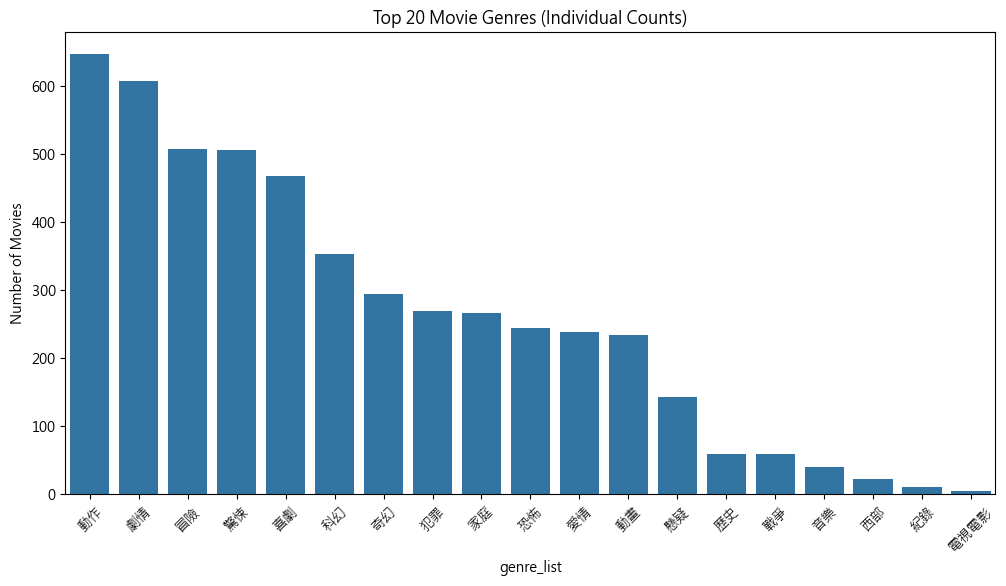

所有類別的數量：
genre_list
動作      647
劇情      608
冒險      507
驚悚      506
喜劇      468
科幻      353
奇幻      295
犯罪      270
家庭      267
恐怖      245
愛情      238
動畫      234
懸疑      143
歷史       59
戰爭       59
音樂       40
西部       23
紀錄       10
電視電影      5
Name: count, dtype: int64


In [6]:
# 步驟 1：先拆解標籤以計算單一標籤的總數
movies['genre_list'] = movies['genre_label'].str.split('、')
df_exploded_temp = movies.explode('genre_list')

# 步驟 2：統計各類別數量
all_genre_counts = df_exploded_temp['genre_list'].value_counts()

# 步驟 3：繪製長條圖
plt.figure(figsize=(12, 6))
# 這裡畫出前 20 個最常見的類別，以免圖表太擠
sns.barplot(x=all_genre_counts.head(20).index, y=all_genre_counts.head(20).values)

plt.title('Top 20 Movie Genres (Individual Counts)')
plt.xticks(rotation=45)
plt.ylabel('Number of Movies')
plt.show()

# 顯示具體的數字給你看
print("所有類別的數量：")
print(all_genre_counts)

In [7]:
# 1. 取得前六名的類別名稱
top_6_genres = all_genre_counts.head(6).index.tolist()
print(f"\n將保留以下前六大類別：{top_6_genres}")

# 2. 在拆解後的資料中，只留下屬於這六類的標籤
df_filtered = df_exploded_temp[df_exploded_temp['genre_list'].isin(top_6_genres)]

# 3. 重新聚合 (Groupby)
# 這裡加入 'words' 欄位的處理
df_final = df_filtered.groupby(df_filtered.index).agg({
    'title': 'first',
    'overview': 'first',
    'words': 'first', # 保留你分好詞的欄位
    'genre_list': lambda x: list(x) 
}).reset_index(drop=True)

# --- 驗證結果 ---
print(f"原始電影總數: {len(movies)}")
print(f"過濾後剩餘電影總數: {len(df_final)}")

# 看看最後一筆資料的樣貌
print("\n將 Explode 完的 genre_list (多 label) 合併回一部電影")
print("處理後的資料：")
print(df_final[['title', 'genre_list', 'words']].head(3))
df_final.head()


將保留以下前六大類別：['動作', '劇情', '冒險', '驚悚', '喜劇', '科幻']
原始電影總數: 1768
過濾後剩餘電影總數: 1666

將 Explode 完的 genre_list (多 label) 合併回一部電影
處理後的資料：
        title genre_list  \
0  超級瑪利歐銀河電影版   [喜劇, 冒險]   
1      阿凡達火與燼   [科幻, 冒險]   
2        極限返航   [科幻, 冒險]   

                                                                             words  
0  超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大喊 先過 這一關 碧姬 公主 則與 奇諾 比奧 迅速 打包 ...  
1  阿凡 達火 這次 故事 敘述 人類 歸化 納美族 並當 首領 傑克 妻子 納美 戰士 奈蒂莉及 蘇里 家人 一同 經歷 奮戰 傷痛 依然 展開 全新 冒...  
2  極限 返航 科學 老師 萊倫 格雷斯 一艘 距離 地球 好幾 光年 太空船 醒來 身分 來到 這裡 原因 一無所知 記憶 逐漸 恢復 揭開 任務 真相 ...  


,title,overview,words,genre_list
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大喊 先過 這一關 碧姬 公主 則與 奇諾 比奧 迅速 打包 ...,"[喜劇, 冒險]"
1,阿凡達火與燼,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,阿凡 達火 這次 故事 敘述 人類 歸化 納美族 並當 首領 傑克 妻子 納美 戰士 奈蒂莉及 蘇里 家人 一同 經歷 奮戰 傷痛 依然 展開 全新 冒...,"[科幻, 冒險]"
2,極限返航,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質導致太陽...,極限 返航 科學 老師 萊倫 格雷斯 一艘 距離 地球 好幾 光年 太空船 醒來 身分 來到 這裡 原因 一無所知 記憶 逐漸 恢復 揭開 任務 真相 ...,"[科幻, 冒險]"
3,降世神通最後的氣宗,安意外得知一股古老力量或許能拯救他的族群免於滅絕在夥伴們的協助下他踏上一段橫跨世界的尋找之旅試圖在這股力量落入歹人之手威脅到他們傾盡一切才換來的和平之前...,降世 神通 最後 氣宗 意外 得知 一股 古老 力量 拯救 族群 免於 滅絕 夥伴 協助 踏上 一段 橫跨 世界 尋找 之旅 試圖 這股 力量 落入 歹...,"[動作, 冒險]"
4,狸想世界,熱愛動物的梅寶逮到了一個機會藉由新科技讓意識進入到栩栩如生的機器動物身上有了能夠和動物溝通的新能力她在自家後院揭開了一個連作夢也想不到的神祕世界,狸想 世界 熱愛 動物 梅寶 逮到 機會 藉由 科技 意識 進入 栩栩如生 機器 動物 身上 能夠 動物 溝通 能力 後院 揭開 連作 想不到 神祕 世界,"[科幻, 喜劇, 冒險]"


# Text Embedding

Text Embedding、word2vec、二維/三維、相似文件、文件分類，以及 BERT 的 NER、情緒分類、關係抽取、主題分群與主題關鍵字。

In [8]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, hamming_loss, classification_report
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

if 'df_final' in globals():
    df_embed = df_final.copy()
elif 'movies' in globals():
    df_embed = movies.copy()
else:
    raise NameError('找不到 df_final 或 movies，請先執行前面的資料處理區塊。')

for col in ['title', 'overview']:
    if col not in df_embed.columns:
        raise ValueError(f'資料缺少必要欄位：{col}')

df_embed = df_embed.dropna(subset=['title', 'overview']).copy()
df_embed['title'] = df_embed['title'].astype(str)
df_embed['overview'] = df_embed['overview'].astype(str)
df_embed['embed_text'] = df_embed['title'] + '。' + df_embed['overview']

if 'words' in df_embed.columns:
    def normalize_words(x):
        if isinstance(x, list):
            return [str(w) for w in x if str(w).strip()]
        return [w for w in str(x).split() if w.strip()]
    df_embed['token_list'] = df_embed['words'].apply(normalize_words)
else:
    df_embed['token_list'] = df_embed['overview'].apply(lambda x: [w for w in jieba.lcut(x) if w.strip()])

print('新增分析資料筆數：', len(df_embed))
display(df_embed[['title', 'overview', 'embed_text', 'token_list']].head(3))

新增分析資料筆數： 1666


,title,overview,embed_text,token_list
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列,超級瑪利歐銀河電影版。面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽...,"[超級, 瑪利, 銀河, 電影版, 面對, 反派, 勢力, 再度, 崛起, 瑪利, 蘑菇, 王國, 挺身而出, 迎戰, 大喊, 先過, 這一關, 碧姬,..."
1,阿凡達火與燼,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,阿凡達火與燼。這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反...,"[阿凡, 達火, 這次, 故事, 敘述, 人類, 歸化, 納美族, 並當, 首領, 傑克, 妻子, 納美, 戰士, 奈蒂莉及, 蘇里, 家人, 一同, ..."
2,極限返航,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質導致太陽...,極限返航。科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物...,"[極限, 返航, 科學, 老師, 萊倫, 格雷斯, 一艘, 距離, 地球, 好幾, 光年, 太空船, 醒來, 身分, 來到, 這裡, 原因, 一無所知,..."


## Text Embedding（一）：Word2Vec 

用電影劇情簡介斷詞結果訓練 Word2Vec，讓模型學到本資料集中的詞彙語意相近程度。

In [9]:
# 環境變數設定
%env PYTHONHASHSEED=2025

env: PYTHONHASHSEED=2025


In [10]:
# ============================================================
# 【新增 1：Text Embedding - Word2Vec 自己訓練】
# 參考檔案：text_embeddings.ipynb 的 word2vec 自訓練流程
# 功能：訓練 Word2Vec，並查詢指定詞彙的相似詞。
# ============================================================

from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=df_embed['token_list'].tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=30,
    seed=RANDOM_STATE
)

# print('Word2Vec 詞彙數：', len(w2v_model.wv.index_to_key))

# query_word = '國王'   # 可改成：警察、家庭、犯罪、愛情
# if query_word in w2v_model.wv:
#     print(f'與「{query_word}」最相似的詞：')
#     display(pd.DataFrame(w2v_model.wv.most_similar(query_word, topn=10), columns=['word', 'similarity']))
# else:
#     print(f'「{query_word}」不在 Word2Vec 詞彙表中，請改查其他詞。')
# 檢查最相關的字
word1 = '國王'
word2 = '魔法'
print(f'與「{word1}」最相似的詞：')
display(pd.DataFrame(w2v_model.wv.most_similar(word1, topn=10), columns=['word', 'similarity']))

print(f'與「{word1} 和 {word2}」最相似的詞：')
display(pd.DataFrame(w2v_model.wv.most_similar([word2,word1], topn=10), columns=['word', 'similarity']))

與「國王」最相似的詞：


,word,similarity
0,哈洛,0.763118
1,王后,0.749046
2,瓦干達,0.740635
3,奧尼達,0.709281
4,教母,0.705226
5,投效,0.693594
6,跟費,0.685770
7,臨死前,0.683091
8,駕崩,0.679286
9,神仙,0.678923


與「國王 和 魔法」最相似的詞：


,word,similarity
0,美人魚,0.771614
1,王后,0.731748
2,方便,0.731511
3,哈洛,0.730067
4,樂佩,0.721169
5,教母,0.718427
6,跟費,0.716390
7,現代科技,0.708853
8,瓦干達,0.707915
9,食死,0.706811


In [11]:
# 檢查最不相關的字
word1 = '國王'
word2 = '魔法'
print(f'與「{word1}」最不相似的詞：')
display(pd.DataFrame(w2v_model.wv.most_similar(negative=word1, topn=10), columns=['word', 'similarity']))

print(f'與「{word1} 和 {word2}」最不相似的詞：')
display(pd.DataFrame(w2v_model.wv.most_similar(negative=[word2,word1], topn=10), columns=['word', 'similarity']))

與「國王」最不相似的詞：


,word,similarity
0,壓力,0.146577
1,派對,0.126613
2,警局,0.121664
3,一見鍾情,0.113204
4,正當,0.110237
5,拍檔,0.106206
6,輾轉,0.105139
7,邁阿密,0.096136
8,某天,0.095337
9,接到,0.093461


與「國王 和 魔法」最不相似的詞：


,word,similarity
0,一年,0.098134
1,壓力,0.078414
2,尼克,0.073526
3,關頭,0.055812
4,警局,0.051448
5,辦案,0.031545
6,交易,0.031377
7,兩人,0.028516
8,媒體,0.018188
9,一見鍾情,0.017643


In [12]:
# 計算兩個字之間的關係
w2v_model.wv.similarity("警長","國王")

0.1119256

In [13]:
# 計算兩個字之間的關係
w2v_model.wv.similarity("警局","拍檔")

0.66369975

In [14]:
# 跟警長和警局最相關的詞
w2v_model.wv.most_similar(positive=["警長"], negative=["警局"], topn=5)

[('依靠', 0.36742815375328064),
 ('幸運', 0.363802433013916),
 ('地表', 0.36142146587371826),
 ('壞人', 0.35765838623046875),
 ('沒牙', 0.34722763299942017)]

## Text Embedding（二）：Word2Vec 二維視覺化

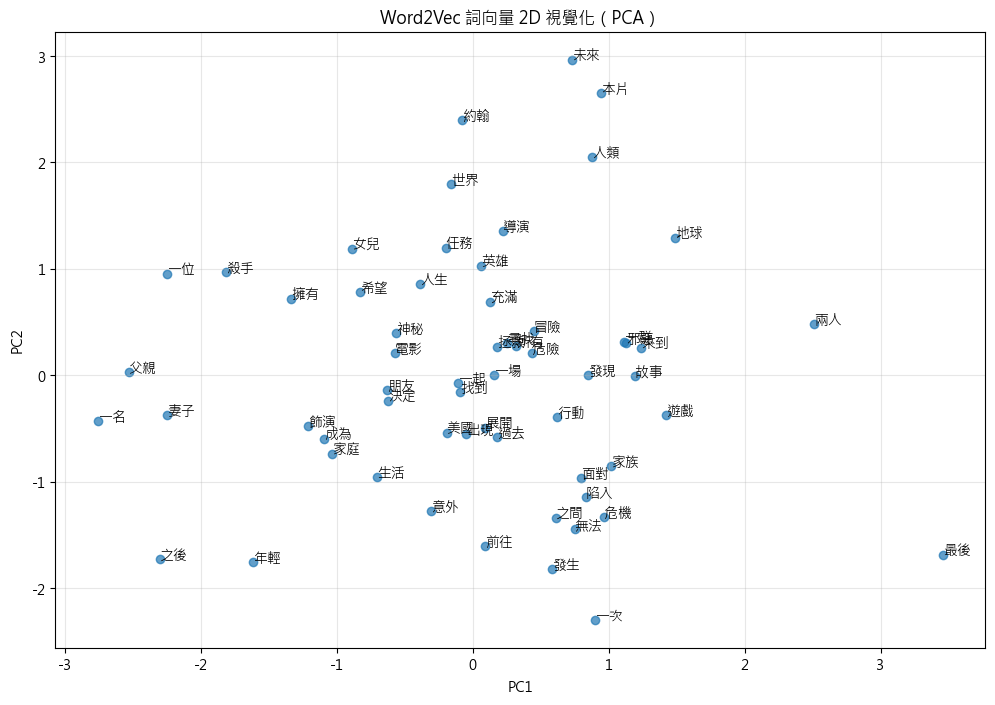

In [15]:
# ============================================================
# 功能：取前 top_n_words 個詞，用 PCA 將 Word2Vec 向量降成 2 維並視覺化。
# ============================================================

top_n_words = 60
vocab_words = w2v_model.wv.index_to_key[:top_n_words]
word_vectors = np.array([w2v_model.wv[w] for w in vocab_words])

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
word_vec_2d = pca_2d.fit_transform(word_vectors)

plt.figure(figsize=(12, 8))
plt.scatter(word_vec_2d[:, 0], word_vec_2d[:, 1], alpha=0.7)
for word, x, y in zip(vocab_words, word_vec_2d[:, 0], word_vec_2d[:, 1]):
    plt.text(x, y, word, fontsize=10)
plt.title('Word2Vec 詞向量 2D 視覺化（PCA）')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.show()

## Text Embedding（三）：Word2Vec 三維視覺化


In [16]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [16]:
from sklearn.manifold import TSNE
import plotly.express as px

# 拿到list of words 的vector
def getVecs(model,words:list):
    vecs = []
    for i in words:
        vecs.append(model.wv[i])
    return np.vstack(vecs)

# 降維：利用PCA tSNE

def reduceDim(mat,method:str='PCA',dim:str=2,perplexity = 25,learning_rate = 400):

    method_dict = {
        "PCA":PCA(n_components=dim,iterated_power = 1000,random_state=0),
        "TSNE":TSNE(n_components=dim,random_state=0,perplexity=perplexity,learning_rate=learning_rate),
    }
    new_feat = method_dict[method].fit_transform(mat)

    return new_feat

# 畫出三維的散佈圖
def plotScatter3D(vec_df):
    vec_df['size'] = .5
    if 'color' not in vec_df.columns:
        vec_df['color'] = 'blue'
    fig = px.scatter_3d(
        vec_df,'dim1','dim2','dim3',text = 'word',width=800, height=800,color = 'color',size = 'size'

    )

    fig.show()

In [17]:
# 取得所有的字
words = w2v_model.wv.key_to_index.keys()

sample_words = np.random.choice(list(words),300,replace=False).tolist()

feat = getVecs(model=w2v_model,words=sample_words)
print(feat.shape)
new_feat = reduceDim(feat,method='TSNE',perplexity=20,learning_rate = 800)
print(new_feat.shape)

(300, 100)
(300, 2)


In [18]:
new_feat = reduceDim(feat,dim = 3,method = 'PCA' )
print(new_feat.shape)
word_df = pd.DataFrame({
    "word":sample_words,
    "dim1":new_feat[:,0],
    "dim2":new_feat[:,1],
    "dim3":new_feat[:,2],
})
plotScatter3D(word_df)

(300, 3)


#### 三維K-Means 分群

In [20]:
#pip install scikit-learn-extra

In [19]:
# 分群
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
# 只使用word vector 去分群
def cluster(X,method = 'kmeans',n = 2):

    method_dict = {
        'kmeans':KMeans(n_clusters=n, random_state=0),
        'kmedos':KMedoids(n_clusters=n, random_state=0)
    }
    method_dict[method].fit(X)
    result = method_dict[method].predict(X)
    return result

In [21]:
new_feat = reduceDim(feat,method='PCA',dim = 20)
d3_feat = reduceDim(feat,method='PCA',dim = 3)
word_df = pd.DataFrame({
    "word":sample_words,
    "color":cluster(new_feat,n=5),
    "dim1":d3_feat[:,0],
    "dim2":d3_feat[:,1],
    "dim3":d3_feat[:,2],

})
plotScatter3D(word_df)

## Text Embedding（四）：BERT / Sentence-Transformer 文件向量

對應圖片：`小模型(BERT) / 大模型`、`相似文件`、`文件分類`。使用 Sentence-Transformer 將每部電影的簡介轉成文件向量。

In [21]:
import sys
print(sys.executable)
import sys

!{sys.executable} -m pip install sentence-transformers

c:\Users\Cynthia\miniconda3\envs\nlp\python.exe


In [22]:
!pip install -U sentence-transformers

#### 使用embedding做NLP任務，分別以bert-base-chinese和paraphrase-multilingual-MiniLM-L12-v2來實作

In [22]:
df_similar = movies[['id','title', 'overview']]
df_similar['overview'] = df_similar['overview'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))

df_similar.head(5)

,id,title,overview
0,1226863,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列
2,83533,阿凡達火與燼,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅
3,687163,極限返航,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質導致太陽...
4,980431,降世神通最後的氣宗,安意外得知一股古老力量或許能拯救他的族群免於滅絕在夥伴們的協助下他踏上一段橫跨世界的尋找之旅試圖在這股力量落入歹人之手威脅到他們傾盡一切才換來的和平之前...
5,1470130,停屍間助手,殯葬學畢業生麗貝卡歐文斯在河畔殯儀館找到一份夜班工作這份工作起初看似平常但很快便變得詭異起來她開始面對可怕的超自然力量


In [23]:
import torch
from sentence_transformers import SentenceTransformer, models, util

# 中文 bert-base-chinese
bert_ch = SentenceTransformer('google-bert/bert-base-chinese')

bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


0

In [24]:
corpus_embeddings = bert_ch.encode(
    df_similar['overview'].tolist(),
    convert_to_tensor=True,
    batch_size=32
)

In [25]:
# 想搜尋的電影名稱
target_movie_name = "飢餓遊戲黎明收割"

# 找出該電影在 df_similar 中的 index
try:
    query_num = df_similar[df_similar['title'] == target_movie_name].index[0]
    print(f"找到電影 '{target_movie_name}'，Index 為: {query_num}")
except IndexError:
    print("找不到電影名稱")

找到電影 '飢餓遊戲黎明收割'，Index 為: 676


In [26]:
query_num = 676   # 指定電影
top_k = 10

query_embedding = bert_ch.encode(
    df_similar['overview'].loc[query_num],
    convert_to_tensor=True
)

cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
top_results = torch.topk(cos_scores, k=top_k)

# 取出相似電影的 index
top_indices = top_results[1].cpu().numpy()
top_scores = top_results[0].cpu().numpy()

# 做成表格
similar_result = df_similar.iloc[top_indices][['title', 'overview']].copy()
similar_result['Score'] = top_scores

# 顯示結果
display(similar_result)

,title,overview,Score
676,飢餓遊戲黎明收割,故事發生在首集飢餓遊戲的年前年輕的黑密契被選中參加第屆飢餓遊戲同時也是第屆大旬祭大旬祭每年舉行一次規則會與往年有所不同這一屆大旬祭每一個行政區都必須派出...,1.000000
771,飢餓遊戲,在北美洲這塊廢墟大陸上有個新興國家施惠國國內有十二個行政區以及一座被行政區圍繞的富饒都城至高無上且專制殘酷的都城每年逼迫十二行政區交出歲至歲的少男少女各...,0.951560
614,飢餓遊戲星火燎原,電影描述凱妮絲珍妮佛勞倫斯飾和比德喬許哈契森飾扭轉不可能獲勝的的情勢從第屆飢餓遊戲生還攜手返回家鄉後凱妮絲發現他們的勝利竟像星火燎原般讓自己變成叛變的象...,0.948492
1056,辦公室大狂殺,史上最殘酷人性試煉名平凡班族某天被困在平日上班的摩天大樓裡廣播系統突然傳來不知人士的聲音恭喜他們獲參加一場社會實驗在接下來的時間裡個人必須用手邊得的物品...,0.945592
196,哈利波特火盃的考驗,霍格華茲魔法學校舉行停辦多年的三巫鬥法大賽全校師生為此興奮不已當火盃選出哈利波特作為第四位鬥士時卻引起全校師生不諒解憑什麼才歲的哈利能跨越歲的年齡限制將...,0.944803
1893,劇場版進擊的巨人完結篇,人類為了躲避巨人威脅而建築高聳巨大城牆躲在城牆中過著苟且偷生的日子一天超大型巨人來襲打破了歷經百年的和平日常紛亂中失去母親的少年艾連葉卡自此發誓要驅逐所...,0.943333
34,弒婚遊戲度開局,在變態富豪拉多馬斯家族的殺人躲貓貓遊戲中倖存後新娘葛蕾絲本以為一切都在遊戲結束後殺戮就隨之終止沒想到發現自己卻進入了這場噩夢遊戲的下一階段而這次她疏遠已...,0.943126
941,時空英豪,自古以來有群人被稱作不朽者唯有斬首能讓他們死亡而在斬殺同族的同時呼喊咒語唯一人能活便能吸收死者的所有智慧與經驗身為不朽者的康納麥勞德隱姓埋名地生活然而一...,0.942039
307,移動迷宮,在末日後的未來世界裡一群記憶被抹去的少年被送至一處監獄迷宮的空間每隔三十天神祕的電梯會送來新的少年與生活必需品迷宮的石牆則於每日早晨開啟晚上關閉為了自由...,0.941951
1190,一級玩家,史蒂芬史匹柏執導這是他年之後再次與華納合作改編同名科幻小說一級玩家最新的冒險動作片一級玩家將電影的背景設在年全世界正瀕臨混亂與瓦解的邊緣人們只能從虛擬世...,0.941795


In [27]:
# ============================================================
# 功能：將每部電影的 embed_text 轉成 BERT sentence embedding。
# ============================================================

import torch
from sentence_transformers import SentenceTransformer

embed_model_name = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('使用裝置：', device)
print('Embedding model：', embed_model_name)

sent_model = SentenceTransformer(embed_model_name, device=device)

EMBED_SAMPLE_SIZE = None  # 若跑太久，可改成 500 或 1000
if EMBED_SAMPLE_SIZE is None:
    df_embed_sample = df_embed.reset_index(drop=True).copy()
else:
    df_embed_sample = df_embed.sample(n=min(EMBED_SAMPLE_SIZE, len(df_embed)), random_state=RANDOM_STATE).reset_index(drop=True)

movie_embeddings = sent_model.encode(
    df_embed_sample['embed_text'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print('文件向量矩陣 shape：', movie_embeddings.shape)

使用裝置： cpu
Embedding model： sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/53 [00:00<?, ?it/s]

文件向量矩陣 shape： (1666, 384)


In [28]:
# ============================================================
# 功能：指定一部電影，用 cosine similarity 找出語意最相似的其他電影。
# ============================================================

def find_similar_movies_by_embedding(movie_title=None, movie_index=0, top_k=10):
    # 使用 BERT sentence embedding 找相似電影
    if movie_title is not None:
        matched_idx = df_embed_sample[df_embed_sample['title'].str.contains(movie_title, na=False)].index
        if len(matched_idx) == 0:
            raise ValueError(f'找不到標題包含「{movie_title}」的電影，請換一個關鍵字。')
        movie_index = matched_idx[0]

    sim_scores = cosine_similarity(movie_embeddings[movie_index].reshape(1, -1), movie_embeddings).ravel()
    result_idx = np.argsort(sim_scores)[::-1][1:top_k+1]
    result = df_embed_sample.iloc[result_idx][['title', 'overview']].copy()
    result['similarity'] = sim_scores[result_idx]

    print('查詢電影：', df_embed_sample.loc[movie_index, 'title'])
    print('劇情簡介：', df_embed_sample.loc[movie_index, 'overview'])
    return result

similar_movies_embedding = find_similar_movies_by_embedding(movie_title='飢餓遊戲黎明收割', top_k=10)
display(similar_movies_embedding)

查詢電影： 飢餓遊戲黎明收割
劇情簡介： 故事發生在首集飢餓遊戲的年前年輕的黑密契被選中參加第屆飢餓遊戲同時也是第屆大旬祭大旬祭每年舉行一次規則會與往年有所不同這一屆大旬祭每一個行政區都必須派出兩倍數量的貢品他們將在飢餓遊戲之中展開生死搏鬥


,title,overview,similarity
617,飢餓遊戲,在北美洲這塊廢墟大陸上有個新興國家施惠國國內有十二個行政區以及一座被行政區圍繞的富饒都城至高無上且專制殘酷的都城每年逼迫十二行政區交出歲至歲的少男少女各...,0.748513
286,飢餓遊戲鳴鳥與游蛇之歌,歲的史諾湯姆布萊斯飾將擔任第十屆飢餓遊戲的導師期待能透過指導貢品贏得比賽振興落魄的家族不料他抽中的貢品是一名來自施惠國最窮困十二區的個性古怪女孩露西瑞秋...,0.697007
495,飢餓遊戲星火燎原,電影描述凱妮絲珍妮佛勞倫斯飾和比德喬許哈契森飾扭轉不可能獲勝的的情勢從第屆飢餓遊戲生還攜手返回家鄉後凱妮絲發現他們的勝利竟像星火燎原般讓自己變成叛變的象...,0.541191
825,五星饗魘,故事講述美食愛好者泰勒與女伴瑪格光顧名廚朱利安史洛威克經營的高級餐廳霍桑品嘗高級饗宴卻連同其他顧客被捲入史洛威克精心安排的驚悚陷阱之中,0.504110
735,羅小黑戰記,小黑跟隨師父在小鎮上過著安甯日子分會館遇襲打破了妖精世界維系多年的和平來自妖靈會館的全新任務也讓兩人陷入分離危機更讓師父無限的處境發生翻天覆地的變化面對...,0.496453
878,鬼擋路,在西維吉尼亞州的一個小鎮一群人在萬聖節舉辦化裝舞會在音樂下狂歡惡作劇山裡的變種食人魔也不請自來到這場舞會中等待這群人的竟是一場不給糖就搗蛋的死亡之旅,0.495204
468,仲夏魘,一對年輕愛侶前往瑞典一座遺世獨立的小村莊參加仲夏節慶典然而隨著慶典儀式愈發詭異失控他們發現自己即將面對超乎想像的恐懼,0.475653
1582,東京喰種,故事發生在漫畫第一部的年前講述了高中時代的有馬貴將和富良太志於區追查喰種燈籠的故事,0.473245
176,大英雄天團,故事設定在一個虛構大都市舊京山中歲的發明天才少年濱田廣在哥哥阿正去世之後與哥哥發明的醫療用機器人杯麵成了好朋友他發現哥哥的死因並不單純為了阻止舊京山的黑...,0.472421
435,男孩我最壞,故事講述兩名互相依賴的高中生麻吉席爾與塞拉眼見畢業在即兩個學校裡不起眼的小人物於是想出一個計劃籌劃的一場瘋狂派對希望可以藉此機會把妹期望正妹會自動投懷送...,0.464184


#### embedding(使用bert-base-chinese模型做embeddings，接著訓練分類器。)


In [29]:
import numpy as np
from ast import literal_eval
from sklearn.metrics import classification_report
import torch
from sentence_transformers import SentenceTransformer

In [30]:
# 中文 bert-base-chinese
bert_ch = SentenceTransformer('google-bert/bert-base-chinese')

bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


0

In [31]:
df_embed["embeddings"] = df_embed.embed_text.apply(lambda x: bert_ch.encode(x))
df_embed.head(3)

,title,overview,words,genre_list,embed_text,token_list,embeddings
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大喊 先過 這一關 碧姬 公主 則與 奇諾 比奧 迅速 打包 ...,"[喜劇, 冒險]",超級瑪利歐銀河電影版。面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽...,"[超級, 瑪利, 銀河, 電影版, 面對, 反派, 勢力, 再度, 崛起, 瑪利, 蘑菇, 王國, 挺身而出, 迎戰, 大喊, 先過, 這一關, 碧姬,...","[0.51676375, -0.045323182, -0.017219098, 0.27022234, 0.20875742, -0.13572697..."
1,阿凡達火與燼,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,阿凡 達火 這次 故事 敘述 人類 歸化 納美族 並當 首領 傑克 妻子 納美 戰士 奈蒂莉及 蘇里 家人 一同 經歷 奮戰 傷痛 依然 展開 全新 冒...,"[科幻, 冒險]",阿凡達火與燼。這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反...,"[阿凡, 達火, 這次, 故事, 敘述, 人類, 歸化, 納美族, 並當, 首領, 傑克, 妻子, 納美, 戰士, 奈蒂莉及, 蘇里, 家人, 一同, ...","[0.70429206, -0.0064358492, -0.024120029, 0.21119545, 0.20148481, 0.20877756..."
2,極限返航,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質導致太陽...,極限 返航 科學 老師 萊倫 格雷斯 一艘 距離 地球 好幾 光年 太空船 醒來 身分 來到 這裡 原因 一無所知 記憶 逐漸 恢復 揭開 任務 真相 ...,"[科幻, 冒險]",極限返航。科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物...,"[極限, 返航, 科學, 老師, 萊倫, 格雷斯, 一艘, 距離, 地球, 好幾, 光年, 太空船, 醒來, 身分, 來到, 這裡, 原因, 一無所知,...","[0.62418544, -0.116615966, -0.041148044, 0.18304682, -0.15670754, -0.0504178..."


In [32]:
data = df_embed.copy()

X = data["embeddings"].apply(pd.Series)
y = data["genre_list"]

# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777
)

print(X_train.head())
print(y_train.head())

           0         1         2         3         4         5         6    \
1025  0.794649 -0.101130 -0.169862  0.186218  0.050392 -0.072900 -0.003383   
875   0.551602 -0.060092 -0.131419  0.223568  0.148658 -0.352589 -0.264520   
723   0.460421 -0.090406 -0.404466 -0.004755  0.132191 -0.140254 -0.166705   
1000  0.709224 -0.147645 -0.041741  0.338963  0.148326 -0.246027 -0.403360   
1522  0.654788 -0.302825  0.036972  0.413117  0.050474 -0.130056 -0.242161   

           7         8         9         10        11        12        13   \
1025  0.112924 -0.320672 -0.088807 -0.284537 -0.537858 -0.055633  0.555615   
875   0.225380 -0.172399 -0.072602 -0.252152 -0.535990 -0.464024  0.085401   
723  -0.095221 -0.258263  0.015556 -0.250432 -0.721055 -0.332075  0.295518   
1000 -0.246676 -0.196522 -0.069109 -0.306185 -0.454663 -0.226369  0.310921   
1522 -0.008042 -0.013727 -0.403963 -0.190603 -0.431773 -0.233241  0.428137   

           14        15        16        17        18        1

In [33]:
# 1. 初始化轉換器
mlb = MultiLabelBinarizer()

# 2. 將 y 轉換為二進位矩陣 (Binary Array)
# 例如 [['A'], ['A', 'B']] 會變成 [[1, 0], [1, 1]]
y_train_bin = mlb.fit_transform(y_train)
y_test_bin = mlb.transform(y_test)

# 3. 注意：LogisticRegression 本身不支援多標籤，需搭配 OneVsRestClassifier
clf = OneVsRestClassifier(LogisticRegression())
clf.fit(X_train, y_train_bin)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegression()
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeight

In [34]:
# 預測
y_pred_bin = clf.predict(X_test)

# 評估（注意：這時 y_test 和 y_pred 都是二進位矩陣）
print(classification_report(y_test_bin, y_pred_bin, target_names=mlb.classes_))

              precision    recall  f1-score   support

          冒險       0.64      0.48      0.55       141
          劇情       0.71      0.69      0.70       185
          動作       0.77      0.73      0.75       195
          喜劇       0.71      0.64      0.67       134
          科幻       0.80      0.61      0.69       115
          驚悚       0.74      0.67      0.70       167

   micro avg       0.73      0.65      0.68       937
   macro avg       0.73      0.64      0.68       937
weighted avg       0.73      0.65      0.68       937
 samples avg       0.72      0.68      0.66       937



# BERT 任務實作

以下對應圖片中的 BERT 區塊：`NER`、`Sentiment Classification`、`Relation Extraction`、`主題分群`、`主題分群關鍵字`。

In [35]:
# ============================================================
# 功能：使用中文 NER 模型辨識電影簡介中的人名、地名、組織等實體。
# ============================================================

from transformers import pipeline

ner_model_name = 'ckiplab/bert-base-chinese-ner'
ner_pipe = pipeline(
    task='ner',
    model=ner_model_name,
    tokenizer=ner_model_name,
    aggregation_strategy='simple',
    device=0 if torch.cuda.is_available() else -1
)

sample_text_for_ner = df_embed_sample.loc[0, 'embed_text'][:450]
print('NER 範例文本：')
print(sample_text_for_ner)

ner_results = ner_pipe(sample_text_for_ner)
ner_df = pd.DataFrame(ner_results)
if not ner_df.empty:
    ner_df = ner_df.rename(columns={'word': 'entity', 'entity_group': 'entity_type'})
    display(ner_df[['entity', 'entity_type', 'score', 'start', 'end']])
else:
    print('此文本未辨識出命名實體。')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

NER 範例文本：
超級瑪利歐銀河電影版。面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列


,entity,entity_type,score,start,end
0,瑪 利 歐 銀,PRODUCT,0.999872,2,6
1,河,PRODUCT,0.999707,6,7
2,電 影,LANGUAGE,0.990636,7,9
3,版,LANGUAGE,0.998547,9,10
4,瑪 利,PERSON,0.999996,21,23
5,歐,PERSON,0.999996,23,24
6,碧,PERSON,0.999984,44,45
7,姬,PERSON,0.999401,45,46
8,奇 諾 比,PERSON,0.999998,50,53
9,奧,PERSON,0.999991,53,54


In [36]:
# 使用 CKIP 開發的 NLP 套件：ckip_transformers

from ckip_transformers.nlp import CkipWordSegmenter, CkipPosTagger, CkipNerChunker
# 初始化 ckip 工具 device=0 使用GPU ｜ device=-1 使用CPU（速度會很慢）
# Mac使用者可以設定 device=torch.device("mps") 使用GPU
ws_driver  = CkipWordSegmenter(model_name="ckiplab/bert-base-chinese-ws") # Word Segmenter斷詞
pos_driver = CkipPosTagger(model_name="ckiplab/bert-base-chinese-pos") # POS tagger 詞性標記
ner_driver = CkipNerChunker(model_name="ckiplab/bert-base-chinese-ner") # NER識別

# 以前50筆資料作為範例
text = movies['content'].tolist()
text = text[:50]

# 執行處理 
ws = ws_driver(text) # 斷詞
pos = pos_driver(ws) # POS
ner = ner_driver(text) # NER

# 將斷詞以及 pos 結果合在一起顯示
def pack_ws_pos_sentece(sentence_ws, sentence_pos):
   assert len(sentence_ws) == len(sentence_pos) # 確認斷詞和POS的長度相同
   res = []
   for word_ws, word_pos in zip(sentence_ws, sentence_pos):
      res.append(f"{word_ws}({word_pos})") # 合併在一起
   return "\u3000".join(res) 

sentences, packed_sentences, entities = [], [], []

# 儲存結果
for sentence, sentence_ws, sentence_pos, sentence_ner in zip(text, ws, pos, ner):
   sentences.append(sentence)
   packed_sentences.append(pack_ws_pos_sentece(sentence_ws, sentence_pos))
   entities.append([str(entity) for entity in sentence_ner])

# 將結果存在一個 dataframe 中
ner_results = pd.DataFrame({
   'sentence': sentences,
   'packed_sentence': packed_sentences,
   'entities': entities
})

ner_results.head(5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Inference: 100%|██████████| 1/1 [00:07<00:00,  7.52s/it]


,sentence,packed_sentence,entities
0,超級瑪利歐銀河電影版面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛...,超級(A) 瑪利歐(Nb) 銀河(Na) 電影版(Na) 面對(VC) 反派(Na) 勢力(Na) 再度(D) 崛起(VH) 瑪利歐(Nb) 也(D) ...,"[NerToken(word='瑪利歐', ner='PERSON', idx=(20, 23)), NerToken(word='碧姬', ner='..."
1,阿凡達火與燼這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,阿凡達(Nb) 火(Na) 與(Caa) 燼(Na) 這(Nep) 次(Nf) 的(DE) 故事(Na) 敘述(VE) 從(P) 人類(Na) 歸化(V...,"[NerToken(word='納美族', ner='NORP', idx=(18, 21)), NerToken(word='納美', ner='NO..."
2,極限返航科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質...,極限(Na) 返航(VA) 科學(Na) 老師(Na) 萊倫格雷斯(Nb) 在(P) 一(Neu) 艘(Nf) 距離(P) 地球(Na) 好幾(Neu)...,"[NerToken(word='萊倫格雷斯', ner='PERSON', idx=(8, 13)), NerToken(word='地球', ner=..."
3,降世神通最後的氣宗安意外得知一股古老力量或許能拯救他的族群免於滅絕在夥伴們的協助下他踏上一段橫跨世界的尋找之旅試圖在這股力量落入歹人之手威脅到他們傾盡一...,降世(VA) 神通(Na) 最後(Nd) 的(DE) 氣(Nb) 宗安(Nb) 意外(VK) 得知(VK) 一(Neu) 股(Nf) 古老(VH) 力量...,[]
4,停屍間助手殯葬學畢業生麗貝卡歐文斯在河畔殯儀館找到一份夜班工作這份工作起初看似平常但很快便變得詭異起來她開始面對可怕的超自然力量,停屍間(Nc) 助手(Na) 殯葬學(VC) 畢業生(Na) 麗貝卡歐文斯(Nb) 在(P) 河畔(Nc) 殯儀館(Nc) 找到(VC) 一(Neu) ...,"[NerToken(word='麗貝卡歐文斯', ner='PERSON', idx=(11, 17)), NerToken(word='一', ner..."


In [37]:
# ============================================================
# 功能：使用中文情緒分類模型判斷電影簡介偏正向或負向。
# ============================================================

# uer/roberta-base-finetuned-jd-binary-chines是先預訓練RoBERTa然後再用 JD 商品評論做 Fine-tuning 的模型
# 比uer/roberta-base-finetuned-jd-binary-chinese快超級無敵多

sentiment_model_name = 'uer/roberta-base-finetuned-jd-binary-chinese'
sentiment_pipe = pipeline(
    task='sentiment-analysis',
    model=sentiment_model_name,
    tokenizer=sentiment_model_name,
    device=0 if torch.cuda.is_available() else -1
)

sentiment_sample = df_embed_sample[['title', 'overview']].head(10).copy()
sentiment_texts = sentiment_sample['overview'].str[:450].tolist()
sentiment_results = sentiment_pipe(sentiment_texts, truncation=True)

sentiment_sample['sentiment_label'] = [r['label'] for r in sentiment_results]
sentiment_sample['sentiment_score'] = [r['score'] for r in sentiment_results]
display(sentiment_sample[['title', 'overview', 'sentiment_label', 'sentiment_score']])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,title,overview,sentiment_label,sentiment_score
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列,positive (stars 4 and 5),0.693922
1,阿凡達火與燼,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,positive (stars 4 and 5),0.985405
2,極限返航,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質導致太陽...,positive (stars 4 and 5),0.985467
3,降世神通最後的氣宗,安意外得知一股古老力量或許能拯救他的族群免於滅絕在夥伴們的協助下他踏上一段橫跨世界的尋找之旅試圖在這股力量落入歹人之手威脅到他們傾盡一切才換來的和平之前...,positive (stars 4 and 5),0.969447
4,狸想世界,熱愛動物的梅寶逮到了一個機會藉由新科技讓意識進入到栩栩如生的機器動物身上有了能夠和動物溝通的新能力她在自家後院揭開了一個連作夢也想不到的神祕世界,positive (stars 4 and 5),0.973907
5,狂鯊風暴,在一場毀滅性的颶風中一個沿海小鎮正奮力對抗大自然的憤怒以及鯊魚的襲擊在傾盆大雨飛散的殘骸和伸手不見五指的黑暗中他們團結一心勇敢面對致命的掠食者努力在風暴...,positive (stars 4 and 5),0.871427
6,凸槌拍檔,在這部重口味尺度炸裂的喜劇中行銷專員布萊德與伊萊賈放手一搏大膽提案讓全方位包覆保險套品牌冠名贊助世界盃沒想到兩人在巴西的酒醉狂歡引爆全球醜聞暴怒球迷窮凶...,positive (stars 4 and 5),0.793098
7,天眼浩劫,一名隱居在蘇格蘭偏遠小島的男子遠離現代社會不與外界接觸卻在拯救一名落海的少女後引發了一連串危機並導致他的住處小島遭到襲擊這迫使他面對自己的過往並作出反擊,positive (stars 4 and 5),0.972056
8,天劫倒數大遷徙,倖存的蓋瑞提一家必須離開安全的格陵蘭島避難所踏上危險的旅程穿越歐洲滿目瘡痍的冰凍荒原尋找新的家園,positive (stars 4 and 5),0.988900
9,荒島囚救,兩個同事在飛機墜毀後成為僅存的生還者困在一座荒島上他們必須拋開過去的恩怨同心協力求生但他們已經不在辦公室裡了於是在這部原創黑色心理驚悚片中爆發了一場令人...,positive (stars 4 and 5),0.884696


In [38]:
# ============================================================
# 功能：先用 BERT NER 抽實體，再用中文關係詞抽取簡單三元組。
# ============================================================

relation_keywords = ['愛上', '遇見', '尋找', '拯救', '追殺', '調查', '保護', '對抗', '發現', '成為']

def simple_bert_ner_relation_extraction(text, max_len=450):
    text = str(text)[:max_len]
    ents = ner_pipe(text)

    entities = [e['word'].replace(' ', '') for e in ents if e.get('word')]
    entities = list(dict.fromkeys([e for e in entities if len(e) >= 2]))

    rows = []

    for rel in relation_keywords:
        if rel in text:
            rel_pos = text.find(rel)

            left_entities = [
                e for e in entities
                if text.find(e) != -1 and text.find(e) < rel_pos
            ]

            right_entities = [
                e for e in entities
                if text.find(e) != -1 and text.find(e) > rel_pos
            ]

            if left_entities and right_entities:
                rows.append({
                    'subject': left_entities[-1],
                    'relation': rel,
                    'object': right_entities[0]
                })

    return pd.DataFrame(rows)


all_re_rows = []

for idx, row in df_embed_sample.head(200).iterrows():
    tmp = simple_bert_ner_relation_extraction(row['embed_text'])

    if not tmp.empty:
        tmp.insert(0, 'title', row['title'])
        all_re_rows.append(tmp)


if all_re_rows:
    re_df = pd.concat(all_re_rows, ignore_index=True)

    # 只顯示圖片中的欄位
    re_df = re_df[['title', 'subject', 'relation', 'object']]

    # 顯示前 5 筆，讓結果像圖片那樣
    display(re_df.head(5))

else:
    print('前 20 筆沒有抽到明確關係，可增加 relation_keywords 或調整 sample 範圍。')

,title,subject,relation,object
0,超級瑪利歐銀河電影版,奇諾比,尋找,羅潔
1,血債軍團,卡洛斯艾斯特拉,成為,百萬富
2,復仇者聯盟,復仇者聯,保護,安危神盾
3,教父,柯里,保護,索洛
4,侏羅紀世界重生,佐菈班奈,發現,數十


#### 使用BERTopic套件進行主題分類

In [39]:
df_embed.head(3)

,title,overview,words,genre_list,embed_text,token_list,embeddings
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大喊 先過 這一關 碧姬 公主 則與 奇諾 比奧 迅速 打包 ...,"[喜劇, 冒險]",超級瑪利歐銀河電影版。面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽...,"[超級, 瑪利, 銀河, 電影版, 面對, 反派, 勢力, 再度, 崛起, 瑪利, 蘑菇, 王國, 挺身而出, 迎戰, 大喊, 先過, 這一關, 碧姬,...","[0.51676375, -0.045323182, -0.017219098, 0.27022234, 0.20875742, -0.13572697..."
1,阿凡達火與燼,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,阿凡 達火 這次 故事 敘述 人類 歸化 納美族 並當 首領 傑克 妻子 納美 戰士 奈蒂莉及 蘇里 家人 一同 經歷 奮戰 傷痛 依然 展開 全新 冒...,"[科幻, 冒險]",阿凡達火與燼。這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反...,"[阿凡, 達火, 這次, 故事, 敘述, 人類, 歸化, 納美族, 並當, 首領, 傑克, 妻子, 納美, 戰士, 奈蒂莉及, 蘇里, 家人, 一同, ...","[0.70429206, -0.0064358492, -0.024120029, 0.21119545, 0.20148481, 0.20877756..."
2,極限返航,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質導致太陽...,極限 返航 科學 老師 萊倫 格雷斯 一艘 距離 地球 好幾 光年 太空船 醒來 身分 來到 這裡 原因 一無所知 記憶 逐漸 恢復 揭開 任務 真相 ...,"[科幻, 冒險]",極限返航。科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物...,"[極限, 返航, 科學, 老師, 萊倫, 格雷斯, 一艘, 距離, 地球, 好幾, 光年, 太空船, 醒來, 身分, 來到, 這裡, 原因, 一無所知,...","[0.62418544, -0.116615966, -0.041148044, 0.18304682, -0.15670754, -0.0504178..."


In [ ]:
pip install bertopic

Note: you may need to restart the kernel to use updated packages.


In [40]:
from hdbscan import HDBSCAN
from bertopic import BERTopic

# 中文文章
docs_zh = df_embed['overview'].tolist()[:500]

# 設定繁體中文詞庫
jieba.set_dictionary('./dict/dict.txt.big')

# 新增 stopwords
with open('./dict/stop_words.txt',encoding="utf-8") as f:
    stopwords = [line.strip() for line in f.readlines()]

# 設定中文 embedding model
bert_sentence_model = SentenceTransformer("google-bert/bert-base-chinese")

# 將中文文章轉換為 embedding
embeddings = bert_sentence_model.encode(docs_zh, show_progress_bar=True)

# 定義不同 clustering layer 所要使用的模型與方法（就用 default 的 HDBSCAN）
hdbscan_model = HDBSCAN()

# 定義一個適合中文的分詞函數
def tokenize_zh(text):
    words = jieba.lcut(text)
    return words

# 建立一個使用 jieba 分詞的 CountVectorizer
jieba_vectorizer = CountVectorizer(tokenizer=tokenize_zh, stop_words=stopwords, analyzer='word', token_pattern=u"(?u)\\b\\w+\\b")

# 使用 BERTopic 進行主題模型建立
zh_topic_model = BERTopic(embedding_model=bert_sentence_model, vectorizer_model=jieba_vectorizer, verbose=True, top_n_words=30)
topics, probs = zh_topic_model.fit_transform(docs_zh, embeddings)

zh_topic_model.get_topic_info()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

2026-05-19 16:04:59,188 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-19 16:05:09,537 - BERTopic - Dimensionality - Completed ✓
2026-05-19 16:05:09,539 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-19 16:05:09,568 - BERTopic - Cluster - Completed ✓
2026-05-19 16:05:09,572 - BERTopic - Representation - Fine-tuning topics using representation models.
Building prefix dict from d:\media\project3\project3\project3\dict\dict.txt.big ...
Loading model from cache C:\Users\程善妮\AppData\Local\Temp\jieba.uc423d163cb0082e6d6c8ad6dc8a00915.cache
Loading model cost 0.962 seconds.
Prefix dict has been built successfully.
2026-05-19 16:05:10,792 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,195,-1_ _後_中_卻,"[ , 後, 中, 卻, 成為, 人, 故事, 生活, 一場, 世界, 飾, 飾演, 展開, 一位, 最, 年, 冒險, 家族, 殺手, 決定, 最後,...",[影片主要講述第二代教父麥克柯里昂的奮鬥歷程同時回憶了第一代教父維多柯里昂創業的艱辛反映了不同歷史時期兩代教父的事業家庭生活麥克為兒子托尼舉行聖餐儀式和...
1,0,111,0_ _中_世界_人類,"[ , 中, 世界, 人類, 武士, 人, 哈利, 最, 宇宙, 卻, 魔法, 展開, 強大, 英雄, 一場, 後, 再度, 成為, 力量, 新, 對抗...",[魔法世界已成為佛地魔爪牙肆虐的危險之地長久以來令人畏懼的戰爭已開打食死人控制了魔法部霍格華茲魔法學校也難逃一劫其最終目標的是制服哈利波特哈利的唯一希望...
2,1,92,1_ _卻_兩人_生活,"[ , 卻, 兩人, 生活, 中, 妻子, 發現, 人, 後, 母親, 小鎮, 年輕, 決定, 無法, 愛情, 工作, 找到, 想要, 家庭, 夢想, ...",[英國小鎮的女孩露易莎一個充滿希望與活力的年輕女孩熱衷於她小小的生活圈但時運不濟她家境不好學歷不高又無預警地被她打工的咖啡店資遣需錢孔急的她無法拒絕地接...
3,2,62,2_ _飾_一名_後,"[ , 飾, 一名, 後, 展開, 一場, 下, 尼克, 神祕, 任務, 高, 成為, 人, 年, 中, 父親, 復仇, 行動, 蜘蛛人, 譚市, 警方...",[任天堂暨照明娛樂共同出品一部改編自最受歡迎電玩遊戲超級瑪利歐兄弟的全新動畫片超級瑪利歐兄弟電影版超級瑪利歐兄弟電影版一片的導演是亞倫霍瓦斯和麥可傑勒尼...
4,3,29,3_地球_人類_中_任務,"[地球, 人類, 中, 任務, , 病毒, 太空, 動物, 恐龍, 瓦力, 未來, 生存, 執行, 最, 拯救, 芙, 小組, 格陵蘭, 面對, 人,...",[由於地球即將毀滅一群探險家扛起人類史上最重要的任務越過已知的銀河在星際間尋找人類未來的可能性未來地球的劇烈氣候變化已影響到農業地球上的農作物難以種植一...
5,4,11,4_丈夫_ _一位_面對,"[丈夫, , 一位, 面對, 發現, 出路, 瑪雅, 毒梟, 深處, 徹底改變, 噩夢, 過往, 小島, 一名, 做出, 迫使, 方法, 揭開, 隊長...",[一對住在森林深處的父女救起了一位被沖到當地河岸邊的受傷年輕女子一位神祕的陌生人和一位冷酷無情的毒梟從此徹底改變了他們的生活毒梟為了徹底除掉她不惜一切代...


In [41]:
zh_topic_model.visualize_topics()

In [43]:
# 估算每個文件對BERTopic每個主題的機率分布
topic_distr, _ = zh_topic_model.approximate_distribution(docs_zh)

100%|██████████| 1/1 [00:01<00:00,  1.54s/it]


In [44]:
# 以第18個文件為例，列出這份文件對每個主題的機率分布
zh_topic_model.visualize_distribution(topic_distr[18])

#### 查看特定文章的主題分佈 

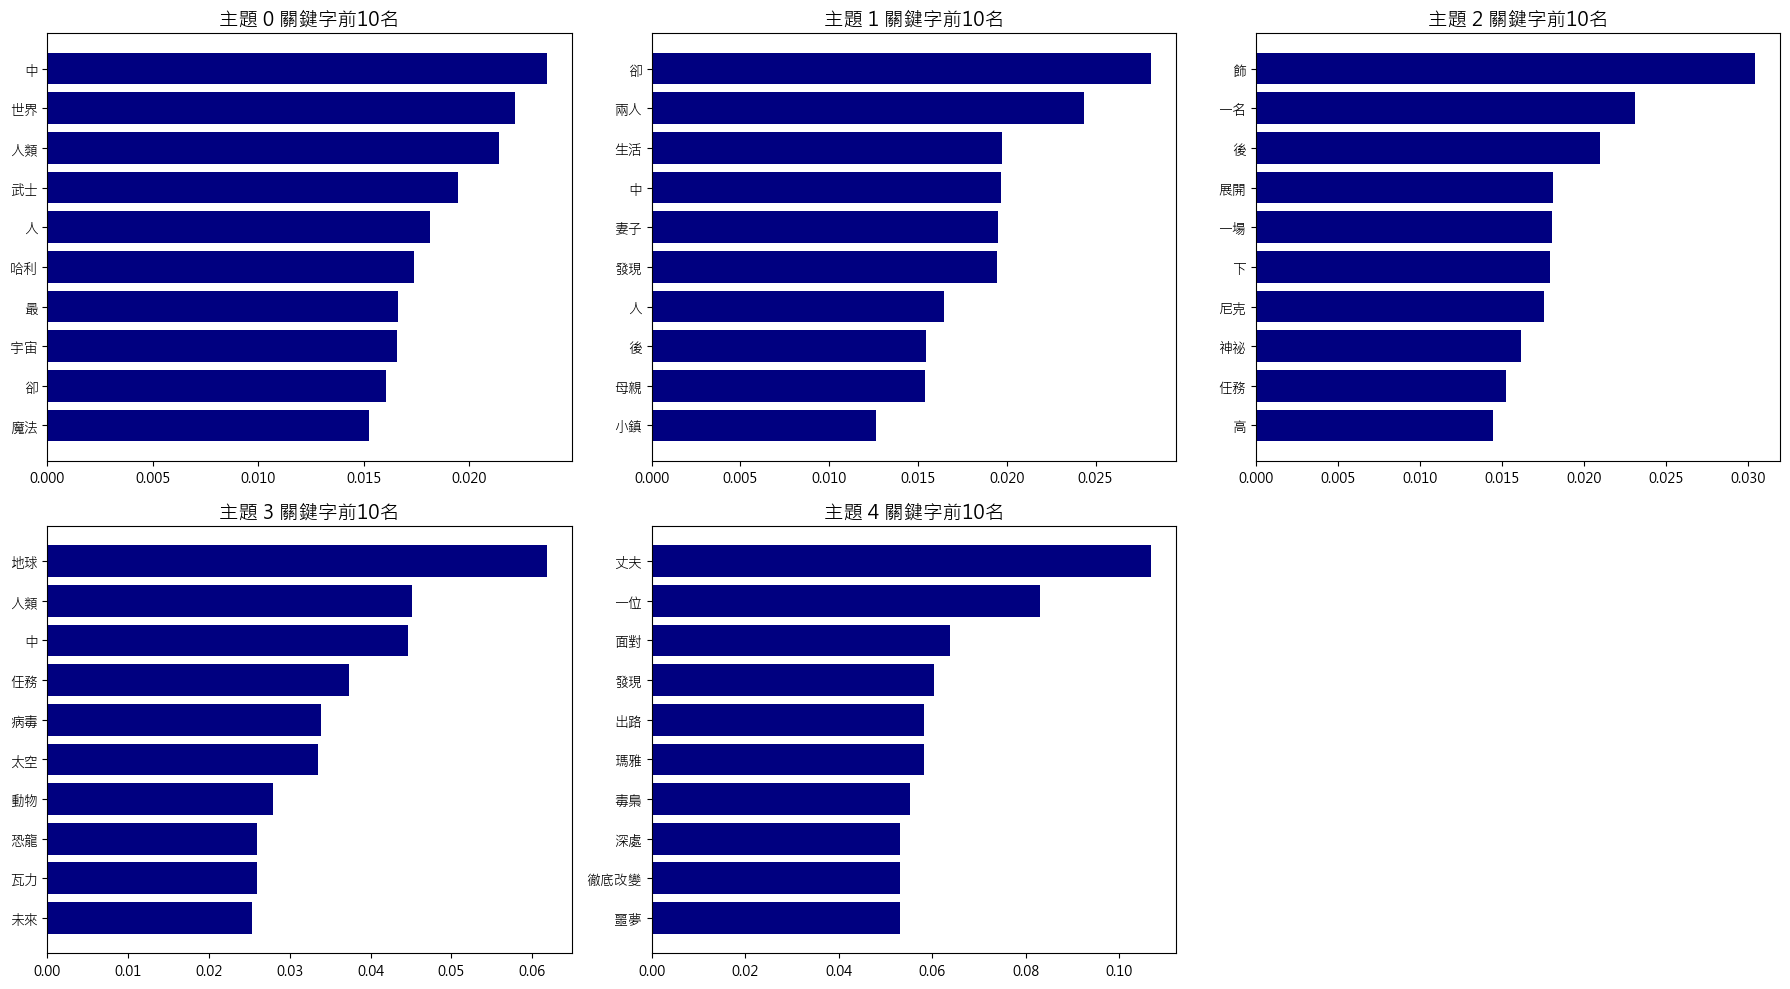

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 設定 2x3 網格 (總共 6 個位置，我們只會用到 5 個)
fig, axes = plt.subplots(2, 3, figsize=(18, 10)) 
axes = axes.flatten() # 壓平為一維陣列，方便用索引訪問 [0, 1, 2, 3, 4, 5]

# 2. 迴圈跑 5 個主題 (Topic 0 到 Topic 4)
for i in range(5):
    # 取得數據
    data = zh_topic_model.get_topic(i)
    
    if data:
        # 轉換為 DataFrame 並清理
        df = pd.DataFrame(data, columns=['word', 'prob'])
        df = df[df['word'].str.strip() != '']
        top_10 = df.sort_values('prob', ascending=False).head(10)
        
        # 在對應的子圖畫圖
        axes[i].barh(top_10['word'], top_10['prob'], color='navy')
        axes[i].set_title(f'主題 {i} 關鍵字前10名', fontsize=14)
        axes[i].invert_yaxis()
    else:
        axes[i].set_title(f'主題 {i} (無資料)', fontsize=14)

# 3. 隱藏最後一個沒用到的小圖 (第 6 個位置)
axes[5].axis('off') 

# 4. 自動調整間距
plt.tight_layout()
plt.show()